In [ ]:
# from histogram_utils import load_group_from_file
# hb = load_group_from_file("small.histos.pkl")
# import matplotlib.pyplot as plt
# import math

# n_layers = hb.n_layers
# n_heads = hb.n_heads

# fig_xsize = 15
# fig_ysize = 10
# aspect = fig_xsize / fig_ysize
# ny = int(math.sqrt(n_heads / aspect))
# nx = int(math.ceil(n_heads / ny))

# fig, axes = plt.subplots(ny, nx, figsize=(fig_xsize, fig_ysize))
# for layer_idx in range(n_layers):
#     fig, axes = plt.subplots(4, 3, figsize=(15, 10))

#     for head_idx in range(n_heads):
#         ax = axes.flatten()[head_idx]
#         h = hb[(layer_idx, head_idx)]
#         ax.bar(h.get_bin_centers(),h.hist(), width=h.bin_dx, alpha=0.7, label=h.name)
#         ax.set_title(h.name)
#         ax.set_yscale('log')

#     plt.savefig(f'plots/panels_L{layer_idx}.pdf')
#     plt.tight_layout()

In [12]:
from histogram_utils import load_group_from_file
hb = load_group_from_file("small.histos.pkl")

In [14]:
dir(hb[(0,0)])

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'bin_centers',
 'bin_dx',
 'bins',
 'draw',
 'fill',
 'fill_stats',
 'from_dict',
 'get_bin_centers',
 'get_statistic',
 'global_opts',
 'hist',
 'hist_n',
 'hist_norm',
 'histograms',
 'load',
 'metadata_attributes',
 'metadata_to_dict',
 'n_entries',
 'n_fill',
 'name',
 'save',
 'set_metadata_from_dict',
 'set_stats',
 'show',
 'stats',
 'stats_functions',
 'stats_values',
 'sum_w',
 'sum_w2',
 'to_dict',
 'use_weights',
 'use_weights_sq']

Looking at moments

In [16]:
hb[0,0].stats()

{'sum': np.float32(81.021835),
 'mean': np.float32(0.00013736612),
 'std': np.float32(0.47700566),
 'max': np.float32(7.736616),
 'min': np.float32(-4.3287435),
 'skew': np.float32(0.21156462),
 'kurtosis': np.float32(4.766994)}

In [18]:
hb[0,1].stats()

{'sum': np.float32(829.11615),
 'mean': np.float32(0.0014057009),
 'std': np.float32(0.46671328),
 'max': np.float32(8.663275),
 'min': np.float32(-3.677007),
 'skew': np.float32(0.24795297),
 'kurtosis': np.float32(4.9053464)}

In [36]:
import numpy as np
import matplotlib.pyplot as plt

In [49]:
t = np.array([v for v in hb.extract_stats('skew').values()])

In [50]:
counts, bins = np.histogram(t, np.linspace(-1.6, 1.6, 256) )

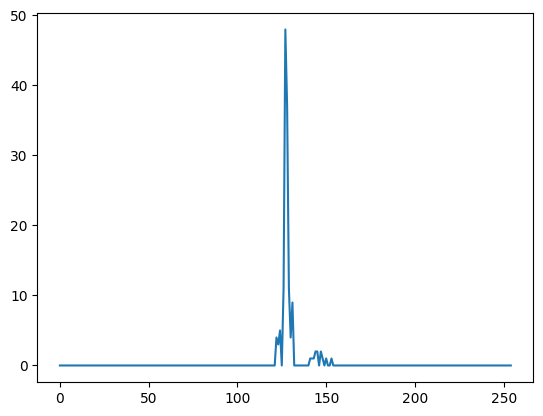

In [52]:
plt.plot(counts)

In [54]:
from histogram_utils import *

In [55]:
kl_vs_empirical_normal(hb[0,0])

np.float64(0.0316666697697285)

In [56]:
normality_metrics["kl_vs_empirical_normal"](hb[0,0])

np.float64(0.0316666697697285)

In [57]:
for k,v in normality_metrics.items():
    print(k, v(hb[0,0]))

kl_vs_standard_normal 0.32439946846977774
kl_vs_empirical_normal 0.0316666697697285
kl_normal_vs_standard 0.35399413
fit_normal {'fit_mu': np.float64(-0.0013823469068544494), 'fit_sigma': np.float64(0.36581225937424144)}


In [58]:
extract_metrics(hb[0,0])

{'kl_vs_standard_normal': np.float64(0.32439946846977774),
 'kl_vs_empirical_normal': np.float64(0.0316666697697285),
 'kl_normal_vs_standard': np.float32(0.35399413),
 'fit_normal': {'fit_mu': np.float64(-0.0013823469068544494),
  'fit_sigma': np.float64(0.36581225937424144)}}

In [60]:
for k, v in hb:
    d = extract_metrics(v)
    v.stats_values.update(d)


In [62]:
hb[0,0].stats_values

{'sum': np.float32(81.021835),
 'mean': np.float32(0.00013736612),
 'std': np.float32(0.47700566),
 'max': np.float32(7.736616),
 'min': np.float32(-4.3287435),
 'skew': np.float32(0.21156462),
 'kurtosis': np.float32(4.766994),
 'kl_vs_standard_normal': np.float64(0.32439946846977774),
 'kl_vs_empirical_normal': np.float64(0.0316666697697285),
 'kl_normal_vs_standard': np.float32(0.35399413),
 'fit_normal': {'fit_mu': np.float64(-0.0013823469068544494),
  'fit_sigma': np.float64(0.36581225937424144)}}

In [68]:
t1 = np.array([v for v in hb.extract_stats('kl_vs_standard_normal').values()])
t2 = np.array([v for v in hb.extract_stats('kl_vs_empirical_normal').values()])
t3 = np.array([v for v in hb.extract_stats('kl_normal_vs_standard').values()])




In [64]:
t

array([0.32439947, 0.32793663, 0.32766452, 0.35370721, 0.29823532,
       0.31256781, 0.31078856, 0.30840803, 0.31513757, 0.32921826,
       0.29074124, 0.30554757, 1.16621033, 1.09876435, 1.15386038,
       1.18792089, 1.13890876, 1.15771544, 1.12205714, 1.1483119 ,
       1.17756719, 1.17459405, 1.15359335, 1.09890888, 0.96646723,
       0.9247746 , 0.94226055, 0.94296661, 0.95359497, 0.93721533,
       0.93966394, 0.90728877, 0.96468526, 0.96307163, 0.93047593,
       0.92229236, 1.01003156, 0.94937874, 0.99882062, 1.00218429,
       0.97788392, 0.98324429, 1.01295561, 0.94320364, 1.0076138 ,
       1.00137485, 1.00113775, 0.98736171, 0.98533075, 0.92531571,
       0.96412949, 0.97818582, 0.95771389, 0.97776093, 0.97043724,
       0.93113441, 0.9745695 , 0.97036769, 0.96825776, 0.97244114,
       1.25463495, 1.24382429, 1.24852577, 1.23789448, 1.24827287,
       1.26106854, 1.24663227, 1.23927127, 1.239955  , 1.24241557,
       1.24353429, 1.23741205, 1.37298318, 1.36639942, 1.37309

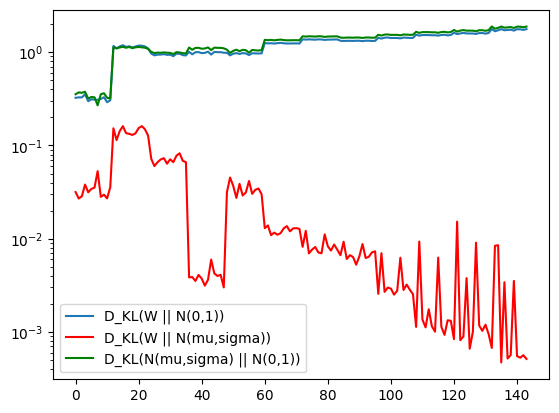

In [75]:
fig, ax = plt.subplots()
ax.plot(t1, label = 'D_KL(W || N(0,1))')
ax.plot(t2, label = 'D_KL(W || N(mu,sigma))', color = 'red')
ax.plot(t3, label = 'D_KL(N(mu,sigma) || N(0,1))', color = 'green')
ax.set_yscale('log')
plt.legend()


In [76]:
import run_weight_analysis

In [77]:
model_shorts

NameError: name 'model_shorts' is not defined

In [78]:
from run_weight_analysis import model_shorts, main